# 📊 Correlation Analysis: หาหุ้นจากทั้งตลาดที่เหมาะกับ Portfolio

## เป้าหมาย
- ดึงหุ้น **ทั้งตลาด** (S&P 500, SET Thai, Chinese ADRs, ETFs) → รวม ~600+ ตัว
- คำนวณ **Correlation** กับหุ้น 30 ตัวใน Portfolio เดิม
- หาหุ้นใหม่ที่มี **Sharpe สูง + Correlation ต่ำ** → ช่วย diversify ได้ดีที่สุด
- สร้าง **Correlation Heatmap** และวิเคราะห์ **M-V Model**

---
### แนวคิด Correlation
- 🔴 **สีแดง (Corr ≈ 1)**: วิ่งไปในทิศทาง **เดียวกัน** → เสี่ยงกระจุก
- 🟢 **สีเขียว (Corr ≈ -1)**: วิ่ง **สวนทางกัน** → diversify ได้ดี
- 🟡 **สีเหลือง (Corr ≈ 0)**: ไม่มีความเกี่ยวข้อง → diversify ได้ดี

## 1. Install & Import Libraries

> **หมายเหตุ:** Dependencies ทั้งหมดถูกจัดการผ่าน `pyproject.toml` + `uv` แล้ว ไม่ต้อง pip install เพิ่ม

In [1]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime, timedelta
import requests
from bs4 import BeautifulSoup
import time
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-darkgrid')
plt.rcParams['figure.figsize'] = (14, 7)
plt.rcParams['font.size'] = 12

print('✅ Libraries loaded successfully!')

✅ Libraries loaded successfully!


## 2. กำหนดหุ้น 30 ตัวเดิมใน Portfolio (อ้างอิง)

In [2]:
stock_sector_map = {
    'AAPL': 'US Technology', 'NVDA': 'US Technology', 'META': 'US Technology',
    'AVGO': 'US Technology', 'GOOGL': 'US Technology',
    'JNJ': 'US Healthcare', 'ABBV': 'US Healthcare', 'LLY': 'US Healthcare',
    'JPM': 'US Financial', 'GS': 'US Financial', 'V': 'US Financial',
    'XOM': 'US Energy', 'MPC': 'US Energy',
    'CAT': 'US Consumer', 'WMT': 'US Consumer', 'COST': 'US Consumer', 'MCD': 'US Consumer',
    'DELTA.BK': 'Thai Stocks', 'ADVANC.BK': 'Thai Stocks', 'KBANK.BK': 'Thai Stocks',
    'PDD': 'Chinese Stocks', 'FUTU': 'Chinese Stocks',
    'BTC-USD': 'Crypto', 'ETH-USD': 'Crypto',
    'HYG': 'Bonds', 'VCSH': 'Bonds', 'EMLC': 'Bonds',
    'GLD': 'Commodities', 'SLV': 'Commodities', 'COPX': 'Commodities',
}
portfolio_tickers = list(stock_sector_map.keys())
print(f'หุ้นเดิมในพอร์ต: {len(portfolio_tickers)} ตัว')
print(f'กลุ่ม: {len(set(stock_sector_map.values()))} กลุ่ม')

หุ้นเดิมในพอร์ต: 30 ตัว
กลุ่ม: 10 กลุ่ม


## 3. ดึงรายชื่อหุ้นจากทุกตลาด

In [3]:
# === 3.1 S&P 500 — ดึงจาก Wikipedia ด้วย pd.read_html (robust กว่า BeautifulSoup) ===
print("📥 ดึงรายชื่อหุ้น S&P 500 จาก Wikipedia...")
try:
    url = 'https://en.wikipedia.org/wiki/List_of_S%26P_500_companies'
    headers = {'User-Agent': 'Mozilla/5.0 (Macintosh; Intel Mac OS X 10_15_7)'}
    resp = requests.get(url, headers=headers, timeout=30)
    from io import StringIO
    tables = pd.read_html(StringIO(resp.text))
    df_sp500 = tables[0]  # ตารางแรกคือ constituents

    # หา column ชื่อ Symbol/Ticker และ GICS Sector
    sym_col = [c for c in df_sp500.columns if 'Symbol' in str(c) or 'Ticker' in str(c)][0]
    sec_col = [c for c in df_sp500.columns if 'GICS Sector' in str(c)][0]

    sp500_tickers = df_sp500[sym_col].str.replace('.', '-', regex=False).tolist()
    sp500_sector_map = dict(zip(
        df_sp500[sym_col].str.replace('.', '-', regex=False),
        df_sp500[sec_col]
    ))

    print(f"  ✅ ได้ {len(sp500_tickers)} ตัว")
except Exception as e:
    print(f"  ❌ ไม่สามารถดึงข้อมูล S&P 500 ได้: {e}")
    sp500_tickers = []
    sp500_sector_map = {}

# === 3.2 SET (Thai Stocks) ===
print("\n📥 รายชื่อหุ้นไทย (SET)...")
thai_tickers_raw = [
    'ADVANC', 'AOT', 'AWC', 'BANPU', 'BBL', 'BDMS', 'BEM', 'BGRIM',
    'BH', 'BTS', 'CBG', 'CENTEL', 'COM7', 'CPALL', 'CPF', 'CPN',
    'CRC', 'DELTA', 'EA', 'EGCO', 'GLOBAL', 'GPSC', 'GULF', 'HMPRO',
    'IVL', 'JMART', 'JMT', 'KBANK', 'KCE', 'KTB', 'KTC',
    'LH', 'MINT', 'MTC', 'OR', 'OSP', 'PTT', 'PTTEP', 'PTTGC',
    'RATCH', 'SAWAD', 'SCB', 'SCC', 'SCGP', 'TISCO', 'TOP',
    'TRUE', 'TTB', 'TU', 'WHA',
    'BEAUTY', 'BCH', 'BCP', 'BJC', 'BLA',
    'GFPT', 'IRPC', 'ITD', 'MAJOR', 'MEGA', 'PLANB',
    'PSL', 'RS', 'SPALI', 'SYNEX',
    'TCAP', 'THANI', 'TPIPP', 'VGI',
]
thai_tickers = [t + '.BK' for t in thai_tickers_raw]
thai_sector_map = {t + '.BK': 'Thai Stocks' for t in thai_tickers_raw}
print(f"  ✅ ได้ {len(thai_tickers)} ตัว")

# === 3.3 Chinese ADRs ===
print("\n📥 รายชื่อหุ้นจีน (ADRs)...")
chinese_tickers = [
    'BABA', 'JD', 'PDD', 'BIDU', 'NIO', 'XPEV', 'LI', 'FUTU',
    'TME', 'BILI', 'IQ', 'ZTO', 'MNSO', 'VNET', 'DIDI',
    'TAL', 'EDU', 'NTES', 'WB', 'HTHT',
]
chinese_sector_map = {t: 'Chinese Stocks' for t in chinese_tickers}
print(f"  ✅ ได้ {len(chinese_tickers)} ตัว")

# === 3.4 ETFs ===
print("\n📥 รายชื่อ ETFs...")
etf_tickers = [
    'TLT', 'IEF', 'SHY', 'LQD', 'HYG', 'VCSH', 'EMLC', 'BND', 'AGG',
    'TIPS', 'MUB', 'BNDX',
    'GLD', 'SLV', 'COPX', 'USO', 'UNG', 'DBA', 'PDBC', 'GSG',
    'PPLT', 'PALL', 'CPER',
    'BTC-USD', 'ETH-USD',
    'EEM', 'VWO', 'EFA', 'VEA', 'MCHI', 'FXI', 'THD',
    'QQQ', 'SPY', 'IWM', 'VTI', 'DIA',
]
etf_sector_map = {
    'TLT': 'Bonds', 'IEF': 'Bonds', 'SHY': 'Bonds', 'LQD': 'Bonds',
    'HYG': 'Bonds', 'VCSH': 'Bonds', 'EMLC': 'Bonds', 'BND': 'Bonds',
    'AGG': 'Bonds', 'TIPS': 'Bonds', 'MUB': 'Bonds', 'BNDX': 'Bonds',
    'GLD': 'Commodities', 'SLV': 'Commodities', 'COPX': 'Commodities',
    'USO': 'Commodities', 'UNG': 'Commodities', 'DBA': 'Commodities',
    'PDBC': 'Commodities', 'GSG': 'Commodities', 'PPLT': 'Commodities',
    'PALL': 'Commodities', 'CPER': 'Commodities',
    'BTC-USD': 'Crypto', 'ETH-USD': 'Crypto',
    'EEM': 'EM ETF', 'VWO': 'EM ETF', 'EFA': 'Intl ETF', 'VEA': 'Intl ETF',
    'MCHI': 'China ETF', 'FXI': 'China ETF', 'THD': 'Thai ETF',
    'QQQ': 'US ETF', 'SPY': 'US ETF', 'IWM': 'US ETF', 'VTI': 'US ETF', 'DIA': 'US ETF',
}
print(f"  ✅ ได้ {len(etf_tickers)} ตัว")

# === รวมทั้งหมด ===
all_tickers = list(set(sp500_tickers + thai_tickers + chinese_tickers + etf_tickers + portfolio_tickers))
all_tickers.sort()

all_sector_map = {}
all_sector_map.update(sp500_sector_map)
all_sector_map.update(thai_sector_map)
all_sector_map.update(chinese_sector_map)
all_sector_map.update(etf_sector_map)

print(f"\n🎯 รวมทั้งหมด: {len(all_tickers)} ตัว (หลังลบ duplicates)")

📥 ดึงรายชื่อหุ้น S&P 500 จาก Wikipedia...
  ✅ ได้ 503 ตัว

📥 รายชื่อหุ้นไทย (SET)...
  ✅ ได้ 69 ตัว

📥 รายชื่อหุ้นจีน (ADRs)...
  ✅ ได้ 20 ตัว

📥 รายชื่อ ETFs...
  ✅ ได้ 37 ตัว

🎯 รวมทั้งหมด: 629 ตัว (หลังลบ duplicates)


## 4. ดาวน์โหลดข้อมูลราคา 4 ปี

⚠️ **อาจใช้เวลา 5-15 นาที**

In [4]:
end_date = datetime.now()
start_date = end_date - timedelta(days=365*4)

print(f"ช่วงเวลา: {start_date.strftime('%Y-%m-%d')} ถึง {end_date.strftime('%Y-%m-%d')}")
print(f"กำลังดาวน์โหลดข้อมูล {len(all_tickers)} ตัว...")
print("⏳ กรุณารอสักครู่...")
print()

batch_size = 50
all_data_list = []

for i in range(0, len(all_tickers), batch_size):
    batch = all_tickers[i:i+batch_size]
    batch_num = i // batch_size + 1
    total_batches = (len(all_tickers) + batch_size - 1) // batch_size
    print(f"  Batch {batch_num}/{total_batches}: downloading {len(batch)} tickers...", end=" ")
    
    try:
        batch_data = yf.download(batch, start=start_date, end=end_date, auto_adjust=True, threads=True)
        # Handle MultiIndex columns from yf.download
        if isinstance(batch_data.columns, pd.MultiIndex):
            batch_close = batch_data['Close']
        else:
            # Single ticker case
            batch_close = batch_data[['Close']].rename(columns={'Close': batch[0]})
        
        all_data_list.append(batch_close)
        n_cols = batch_close.shape[1] if isinstance(batch_close, pd.DataFrame) else 1
        print(f"✅ ได้ {n_cols} ตัว")
    except Exception as e:
        print(f"❌ Error: {e}")
    
    time.sleep(1)

# รวมข้อมูลทุก batch
all_data = pd.concat(all_data_list, axis=1)
all_data = all_data.loc[:, ~all_data.columns.duplicated()]

print(f"\n📊 ดาวน์โหลดได้ทั้งหมด: {all_data.shape[1]} ตัว, {all_data.shape[0]} วัน")

ช่วงเวลา: 2022-03-21 ถึง 2026-03-20
กำลังดาวน์โหลดข้อมูล 629 ตัว...
⏳ กรุณารอสักครู่...

  Batch 1/13: downloading 50 tickers... 

[*********************100%***********************]  50 of 50 completed


✅ ได้ 50 ตัว
  Batch 2/13: downloading 50 tickers... 

[*********************100%***********************]  50 of 50 completed


✅ ได้ 50 ตัว
  Batch 3/13: downloading 50 tickers... 

...

✅ ได้ 50 ตัว
  Batch 12/13: downloading 50 tickers... 

[*********************100%***********************]  50 of 50 completed


✅ ได้ 50 ตัว
  Batch 13/13: downloading 29 tickers... 

[*********************100%***********************]  29 of 29 completed


✅ ได้ 29 ตัว

📊 ดาวน์โหลดได้ทั้งหมด: 629 ตัว, 1461 วัน


In [5]:
# กรองเฉพาะหุ้นที่มีข้อมูลเพียงพอ
# หมายเหตุ: Crypto (BTC, ETH) เทรดทุกวัน (~1460 วัน/4ปี)
# แต่หุ้นปกติเทรดแค่วันทำงาน (~1003 วัน/4ปี)
# ดังนั้นใช้ threshold ที่เหมาะสมกว่า: ≥750 วัน (ประมาณ 3 ปีของวันทำงาน)
min_data_days = 750

valid_cols = [col for col in all_data.columns if int(all_data[col].notna().sum()) >= min_data_days]
data_filtered = all_data[valid_cols].ffill().bfill()
data_filtered = data_filtered.dropna(how='all')

print(f"หุ้นที่มีข้อมูลเพียงพอ (≥{min_data_days} วัน): {len(valid_cols)} ตัว")
print(f"หลังลบ NaN rows: {data_filtered.shape[0]} วัน x {data_filtered.shape[1]} ตัว")

portfolio_in_data = [t for t in portfolio_tickers if t in data_filtered.columns]
portfolio_missing = [t for t in portfolio_tickers if t not in data_filtered.columns]
print(f"\nหุ้นเดิมที่มีข้อมูล: {len(portfolio_in_data)}/{len(portfolio_tickers)} ตัว")
if portfolio_missing:
    print(f"⚠️ หุ้นเดิมที่ขาด: {portfolio_missing}")
    
if len(data_filtered.columns) == 0:
    print("❌ ไม่มีหุ้นตัวไหนผ่านเกณฑ์ข้อมูล")


หุ้นที่มีข้อมูลเพียงพอ (≥750 วัน): 621 ตัว
หลังลบ NaN rows: 1461 วัน x 621 ตัว

หุ้นเดิมที่มีข้อมูล: 30/30 ตัว


In [6]:
# Currency Conversion: All Prices to THB
print("Downloading USD/THB exchange rate...")
try:
    usdthb_raw = yf.download("USDTHB=X", start=start_date, end=end_date, auto_adjust=True)
    if isinstance(usdthb_raw.columns, pd.MultiIndex):
        usdthb = usdthb_raw['Close'].iloc[:, 0]
    else:
        usdthb = usdthb_raw['Close']
    usdthb = usdthb.reindex(data_filtered.index).ffill().bfill()
    print(f"  USD/THB range: {float(usdthb.min()):.2f} - {float(usdthb.max()):.2f}")
except Exception as e:
    print(f"  Warning: Could not download USD/THB ({e})")
    print("  Using fixed rate: 35.00 THB/USD")
    usdthb = pd.Series(35.0, index=data_filtered.index)

data_thb = data_filtered.copy()
thai_cols = [t for t in data_filtered.columns if t.endswith(".BK")]
usd_cols = [t for t in data_filtered.columns if not t.endswith(".BK")]

for ticker in usd_cols:
    data_thb[ticker] = data_filtered[ticker] * usdthb.values.flatten()

print(f"\nConverted {len(usd_cols)} USD assets to THB")
print(f"Thai assets ({len(thai_cols)}): already in THB")

data = data_thb

[*********************100%***********************]  1 of 1 completed

  USD/THB range: 30.91 - 38.30

Converted 553 USD assets to THB
Thai assets (68): already in THB


## 5. คำนวณ Returns & Sharpe Ratio

In [7]:
returns = data.pct_change().dropna()

if not returns.empty:
    annual_returns = returns.mean() * 252
    annual_volatility = returns.std() * np.sqrt(252)
    sharpe_ratios = annual_returns / annual_volatility
    
    all_summary = pd.DataFrame({
        'Sector': [all_sector_map.get(t, 'Unknown') for t in returns.columns],
        'Annual Return (%)': (annual_returns * 100).round(2),
        'Annual Vol (%)': (annual_volatility * 100).round(2),
        'Sharpe Ratio': sharpe_ratios.round(3),
    })
    
    print(f"คำนวณสถิติได้: {len(all_summary)} ตัว")
    print(f"\nTop 20 Sharpe Ratio (ทุกตลาด):")
    print("=" * 70)
    display(all_summary.sort_values('Sharpe Ratio', ascending=False).head(20))
else:
    print("ไม่มีข้อมูลสำหรับการคำนวณสถิติ")
    sharpe_ratios = pd.Series(dtype=float)


คำนวณสถิติได้: 621 ตัว

Top 20 Sharpe Ratio (ทุกตลาด):


,Sector,Annual Return (%),Annual Vol (%),Sharpe Ratio
Ticker,,,,
FIX,Industrials,54.16,39.33,1.377
HWM,Industrials,35.06,26.97,1.300
EME,Industrials,36.08,29.35,1.229
TIPS,Bonds,425.44,351.86,1.209
GE,Industrials,30.88,25.92,1.192
CAH,Health Care,25.84,21.73,1.189
KTB.BK,Thai Stocks,21.58,18.69,1.155
WDC,Information Technology,44.24,41.20,1.074
VST,Utilities,43.67,42.57,1.026


## 6. Correlation Heatmap (30 ตัวเดิม)

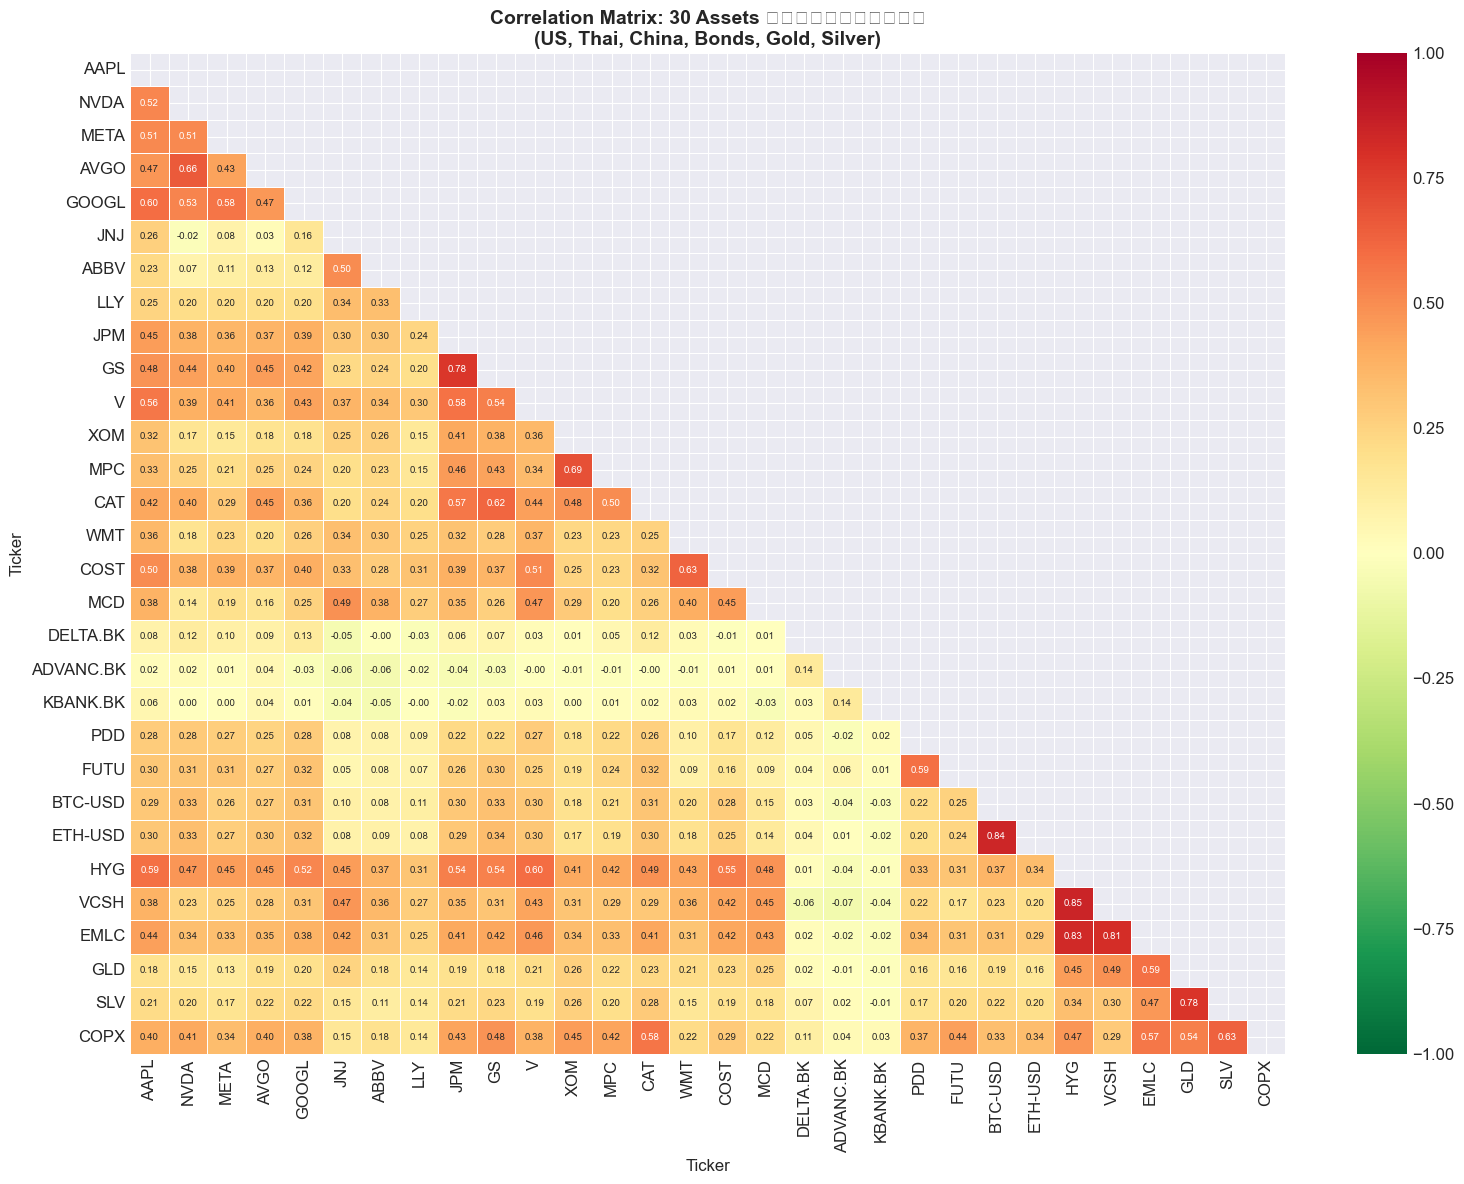

In [8]:
portfolio_cols = [t for t in portfolio_in_data if t in returns.columns]

if len(portfolio_cols) > 1:
    returns_portfolio = returns[portfolio_cols]
    
    fig, ax = plt.subplots(figsize=(16, 12))
    corr_matrix = returns_portfolio.corr()
    mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
    sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='RdYlGn_r',
                center=0, linewidths=0.5, ax=ax, vmin=-1, vmax=1,
                annot_kws={'size': 7})
    ax.set_title('Correlation Matrix: 30 Assets ในพอร์ตเดิม\n(US, Thai, China, Bonds, Gold, Silver)',
                 fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()
else:
    print(f"ไม่สามารถสร้าง heatmap ได้ มีหุ้นพอร์ตเดิมเพียง {len(portfolio_cols)} ตัว")

## 7. 🔍 หาหุ้นใหม่ที่เหมาะกับพอร์ต

**Diversification Score** = `Sharpe × (1 - Avg Corr)` → Sharpe สูง + Corr ต่ำ = คะแนนสูง

In [9]:
if len(portfolio_cols) > 0 and len(returns.columns) > 0:
    corr_all = returns.corr()
    new_tickers = [t for t in returns.columns if t not in portfolio_tickers]
    print(f"หุ้นใหม่ที่ไม่ได้อยู่ในพอร์ตเดิม: {len(new_tickers)} ตัว")

    results = []
    for ticker in new_tickers:
        if ticker not in corr_all.columns or ticker not in sharpe_ratios.index:
            continue
        
        valid_portfolio_cols = [c for c in portfolio_cols if c in corr_all.columns]
        if len(valid_portfolio_cols) == 0:
            continue
        
        avg_corr = corr_all.loc[ticker, valid_portfolio_cols].mean()
        max_corr = corr_all.loc[ticker, valid_portfolio_cols].max()
        min_corr = corr_all.loc[ticker, valid_portfolio_cols].min()
        sharpe = float(sharpe_ratios.loc[ticker])
        annual_ret = float(annual_returns.loc[ticker]) * 100
        annual_vol = float(annual_volatility.loc[ticker]) * 100
        sector = all_sector_map.get(ticker, 'Unknown')
        
        if pd.isna(sharpe) or pd.isna(avg_corr):
            continue
        
        results.append({
            'Ticker': ticker,
            'Sector': sector,
            'Annual Return (%)': round(annual_ret, 2),
            'Annual Vol (%)': round(annual_vol, 2),
            'Sharpe': round(sharpe, 3),
            'Avg Corr (vs Portfolio)': round(float(avg_corr), 3),
            'Max Corr': round(float(max_corr), 3),
            'Min Corr': round(float(min_corr), 3),
        })

    if results:
        candidates_df = pd.DataFrame(results)
        good_candidates = candidates_df[candidates_df['Sharpe'] > 0.5].copy()
        
        if not good_candidates.empty:
            good_candidates['Diversification Score'] = (
                good_candidates['Sharpe'] * (1 - good_candidates['Avg Corr (vs Portfolio)'])
            ).round(3)
            good_candidates = good_candidates.sort_values('Diversification Score', ascending=False)

            print(f"\nหุ้นใหม่ที่ผ่านเกณฑ์ (Sharpe > 0.5): {len(good_candidates)} ตัว")

            # === Stratified Top 30: ให้ครบทุก 10 กลุ่ม (Sector) ===
            target_sectors = [
                'Bonds', 'Chinese Stocks', 'Commodities', 'Crypto', 'Thai Stocks',
                'US Consumer', 'US Energy', 'US Financial', 'US Healthcare', 'US Technology'
            ]
            TOP_N = 30
            MIN_PER_SECTOR = 3  # เลือกอย่างน้อย 3 ตัวต่อกลุ่ม

            selected = pd.DataFrame()
            remaining = good_candidates.copy()

            # ขั้นที่ 1: เลือกหุ้นดีสุดจากแต่ละกลุ่ม (Sector) อย่างน้อย MIN_PER_SECTOR ตัว
            for sector in target_sectors:
                sector_stocks = remaining[remaining['Sector'] == sector]
                if not sector_stocks.empty:
                    take_n = min(MIN_PER_SECTOR, len(sector_stocks))
                    top_sector = sector_stocks.head(take_n)
                    selected = pd.concat([selected, top_sector])
                    remaining = remaining[~remaining['Ticker'].isin(top_sector['Ticker'])]

            # ขั้นที่ 2: เติมที่เหลือด้วยหุ้นที่มี Diversification Score สูงสุด
            slots_left = TOP_N - len(selected)
            if slots_left > 0 and not remaining.empty:
                fill = remaining.head(slots_left)
                selected = pd.concat([selected, fill])

            # จัดเรียงตาม Diversification Score
            selected = selected.sort_values('Diversification Score', ascending=False)

            # แสดงสรุปจำนวนหุ้นในแต่ละกลุ่ม
            print("\n" + "=" * 100)
            print("🏆 Top 30 หุ้นที่เหมาะกับพอร์ตมากที่สุด (Diversification Score สูงสุด)")
            print("   ✅ คัดเลือกแบบ Stratified: มีตัวแทนจากทุก 10 กลุ่ม (Sector)")
            print("=" * 100)
            print("   Diversification Score = Sharpe × (1 - Avg Corr)")

            print("\n📊 สรุปจำนวนหุ้นในแต่ละกลุ่ม:")
            sector_counts = selected.groupby('Sector').size().reset_index(name='จำนวน')
            for _, row in sector_counts.iterrows():
                print(f"   • {row['Sector']:20s}: {row['จำนวน']} ตัว")
            print(f"   {'─' * 30}")
            print(f"   รวมทั้งหมด: {len(selected)} ตัว\n")

            display(selected.set_index('Ticker'))
        else:
            print("\n❌ ไม่มีหุ้นใหม่ที่มี Sharpe > 0.5")
            good_candidates = pd.DataFrame()
    else:
        print("\n❌ ไม่มีหุ้นใหม่ที่สามารถคำนวณหา Correlation ได้ (อาจจะข้อมูลไม่พอ)")
        good_candidates = pd.DataFrame()
else:
    print("\n❌ ไม่มีข้อมูลหุ้นเพียงพอในการเปรียบเทียบ")
    good_candidates = pd.DataFrame()

หุ้นใหม่ที่ไม่ได้อยู่ในพอร์ตเดิม: 591 ตัว

หุ้นใหม่ที่ผ่านเกณฑ์ (Sharpe > 0.5): 135 ตัว

🏆 Top 30 หุ้นที่เหมาะกับพอร์ตมากที่สุด (Diversification Score สูงสุด)
   ✅ คัดเลือกแบบ Stratified: มีตัวแทนจากทุก 10 กลุ่ม (Sector)
   Diversification Score = Sharpe × (1 - Avg Corr)

📊 สรุปจำนวนหุ้นในแต่ละกลุ่ม:
   • Bonds               : 1 ตัว
   • Chinese Stocks      : 2 ตัว
   • Commodities         : 1 ตัว
   • Communication Services: 1 ตัว
   • Consumer Discretionary: 1 ตัว
   • Financials          : 2 ตัว
   • Health Care         : 4 ตัว
   • Industrials         : 5 ตัว
   • Information Technology: 5 ตัว
   • Thai Stocks         : 5 ตัว
   • Utilities           : 3 ตัว
   ──────────────────────────────
   รวมทั้งหมด: 30 ตัว



,Sector,Annual Return (%),Annual Vol (%),Sharpe,Avg Corr (vs Portfolio),Max Corr,Min Corr,Diversification Score
Ticker,,,,,,,,
TIPS,Bonds,425.44,351.86,1.209,0.013,0.061,-0.025,1.193
KTB.BK,Thai Stocks,21.58,18.69,1.155,0.010,0.471,-0.070,1.143
FIX,Industrials,54.16,39.33,1.377,0.260,0.516,-0.025,1.019
TISCO.BK,Thai Stocks,8.44,8.45,0.999,0.018,0.310,-0.066,0.981
CAH,Health Care,25.84,21.73,1.189,0.212,0.394,-0.089,0.937
EME,Industrials,36.08,29.35,1.229,0.278,0.532,-0.030,0.887
HWM,Industrials,35.06,26.97,1.300,0.322,0.559,-0.048,0.881
TTB.BK,Thai Stocks,14.99,16.97,0.883,0.024,0.360,-0.050,0.862
GE,Industrials,30.88,25.92,1.192,0.313,0.534,-0.014,0.819


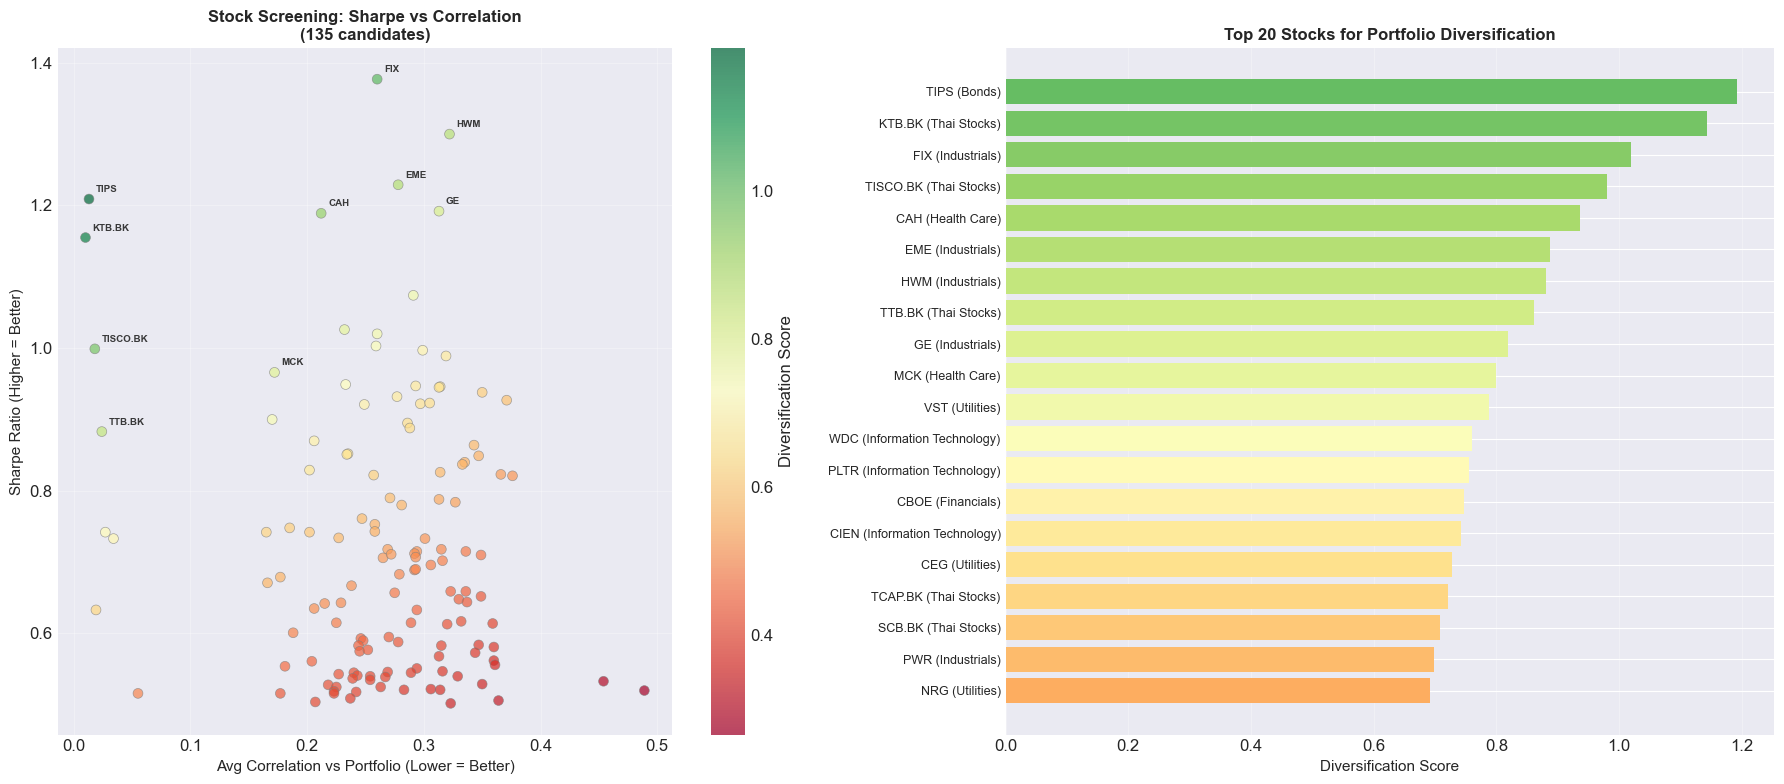

In [10]:
# Visualization
if not good_candidates.empty:
    top_n = min(20, len(good_candidates))
    top_candidates = good_candidates.head(top_n)
    
    fig, axes = plt.subplots(1, 2, figsize=(18, 8))
    
    # Scatter: Sharpe vs Avg Correlation
    ax1 = axes[0]
    scatter = ax1.scatter(
        good_candidates['Avg Corr (vs Portfolio)'],
        good_candidates['Sharpe'],
        c=good_candidates['Diversification Score'],
        cmap='RdYlGn', s=50, alpha=0.7, edgecolors='gray', linewidths=0.5
    )
    for _, row in top_candidates.head(10).iterrows():
        ax1.annotate(row['Ticker'], (row['Avg Corr (vs Portfolio)'], row['Sharpe']),
                    fontsize=7, fontweight='bold', alpha=0.9,
                    xytext=(5, 5), textcoords='offset points')
    plt.colorbar(scatter, ax=ax1, label='Diversification Score')
    ax1.set_xlabel('Avg Correlation vs Portfolio (Lower = Better)', fontsize=11)
    ax1.set_ylabel('Sharpe Ratio (Higher = Better)', fontsize=11)
    ax1.set_title(f'Stock Screening: Sharpe vs Correlation\n({len(good_candidates)} candidates)',
                  fontsize=12, fontweight='bold')
    ax1.grid(True, alpha=0.3)
    
    # Bar chart: Top N
    ax2 = axes[1]
    y_pos = np.arange(top_n)
    colors = plt.cm.RdYlGn(np.linspace(0.8, 0.3, top_n))
    ax2.barh(y_pos, top_candidates['Diversification Score'].values, color=colors)
    ax2.set_yticks(y_pos)
    ax2.set_yticklabels([f"{row['Ticker']} ({row['Sector']})" for _, row in top_candidates.iterrows()], fontsize=9)
    ax2.invert_yaxis()
    ax2.set_xlabel('Diversification Score', fontsize=11)
    ax2.set_title(f'Top {top_n} Stocks for Portfolio Diversification',
                  fontsize=12, fontweight='bold')
    ax2.grid(True, alpha=0.3, axis='x')
    
    plt.tight_layout()
    plt.show()
else:
    print("ไม่มีข้อมูลพอที่จะสร้าง Visualization สำหร้บหุ้นใหม่")

## 8. M-V Model: Correlation/Covariance Analysis

In [11]:
if len(portfolio_cols) > 1:
    mu = returns[portfolio_cols].mean() * 252
    cov = returns[portfolio_cols].cov() * 252
    corr = returns[portfolio_cols].corr()
    
    print("=" * 65)
    print("หัวใจ M-V Model: ทำไม Correlation สำคัญ?")
    print("=" * 65)
    
    corr_pairs = []
    tickers_list = list(corr.columns)
    for i in range(len(tickers_list)):
        for j in range(i+1, len(tickers_list)):
            corr_pairs.append((tickers_list[i], tickers_list[j], corr.iloc[i,j]))
    corr_pairs.sort(key=lambda x: x[2])
    
    print("\nCorrelation ต่ำสุด (diversify ได้ดี):")
    for a, b, c in corr_pairs[:5]:
        print(f"  {a:10s} vs {b:10s}  corr = {c:+.3f}  {'<-- negative!' if c < 0 else ''}")
    
    print("\nCorrelation สูงสุด (เสี่ยงกระจุก):")
    for a, b, c in corr_pairs[-5:]:
        print(f"  {a:10s} vs {b:10s}  corr = {c:+.3f}")
    
    print("\n" + "=" * 65)
    print("พิสูจน์: เปรียบเทียบ 2-asset portfolio")
    print("=" * 65)
    
    high_a, high_b, high_c = corr_pairs[-1]
    low_a, low_b, low_c = corr_pairs[0]
    
    def two_asset_portfolio(t1, t2, w1=0.5):
        w2 = 1 - w1
        ret = w1 * mu[t1] + w2 * mu[t2]
        var = w1**2 * cov.loc[t1,t1] + w2**2 * cov.loc[t2,t2] + 2*w1*w2*cov.loc[t1,t2]
        vol = np.sqrt(var)
        avg_vol = w1 * np.sqrt(cov.loc[t1,t1]) + w2 * np.sqrt(cov.loc[t2,t2])
        diversification = (1 - vol/avg_vol) * 100
        return ret, vol, avg_vol, diversification
    
    ret_h, vol_h, avg_vol_h, div_h = two_asset_portfolio(high_a, high_b)
    ret_l, vol_l, avg_vol_l, div_l = two_asset_portfolio(low_a, low_b)
    
    print(f"\nCase 1: HIGH Corr ({high_a} + {high_b}, corr={high_c:+.3f})")
    print(f"  Average Vol  = {avg_vol_h*100:.2f}%")
    print(f"  Portfolio Vol = {vol_h*100:.2f}%")
    print(f"  Diversification = {div_h:.1f}%  <-- น้อย!")
    
    print(f"\nCase 2: LOW Corr ({low_a} + {low_b}, corr={low_c:+.3f})")
    print(f"  Average Vol  = {avg_vol_l*100:.2f}%")
    print(f"  Portfolio Vol = {vol_l*100:.2f}%")
    print(f"  Diversification = {div_l:.1f}%  <-- สูงกว่ามาก!")
    
    print(f"\n>> สรุป: Corr ต่ำ -> ลดความเสี่ยงได้ {div_l:.1f}% vs Corr สูง -> ลดได้แค่ {div_h:.1f}%")
else:
    print("ไม่มีข้อมูลหุ้นพอร์ตเดิมมากพอที่จะวิเคราะห์ 2-asset portfolio ได้")

หัวใจ M-V Model: ทำไม Correlation สำคัญ?

Correlation ต่ำสุด (diversify ได้ดี):
  ADVANC.BK  vs VCSH        corr = -0.066  <-- negative!
  ABBV       vs ADVANC.BK   corr = -0.061  <-- negative!
  DELTA.BK   vs VCSH        corr = -0.060  <-- negative!
  JNJ        vs ADVANC.BK   corr = -0.059  <-- negative!
  JNJ        vs DELTA.BK    corr = -0.052  <-- negative!

Correlation สูงสุด (เสี่ยงกระจุก):
  GLD        vs SLV         corr = +0.784
  VCSH       vs EMLC        corr = +0.807
  HYG        vs EMLC        corr = +0.826
  BTC-USD    vs ETH-USD     corr = +0.840
  HYG        vs VCSH        corr = +0.849

พิสูจน์: เปรียบเทียบ 2-asset portfolio

Case 1: HIGH Corr (HYG + VCSH, corr=+0.849)
  Average Vol  = 8.57%
  Portfolio Vol = 8.25%
  Diversification = 3.8%  <-- น้อย!

Case 2: LOW Corr (ADVANC.BK + VCSH, corr=-0.066)
  Average Vol  = 11.76%
  Portfolio Vol = 8.64%
  Diversification = 26.5%  <-- สูงกว่ามาก!

>> สรุป: Corr ต่ำ -> ลดความเสี่ยงได้ 26.5% vs Corr สูง -> ลดได้แค่ 3.8%


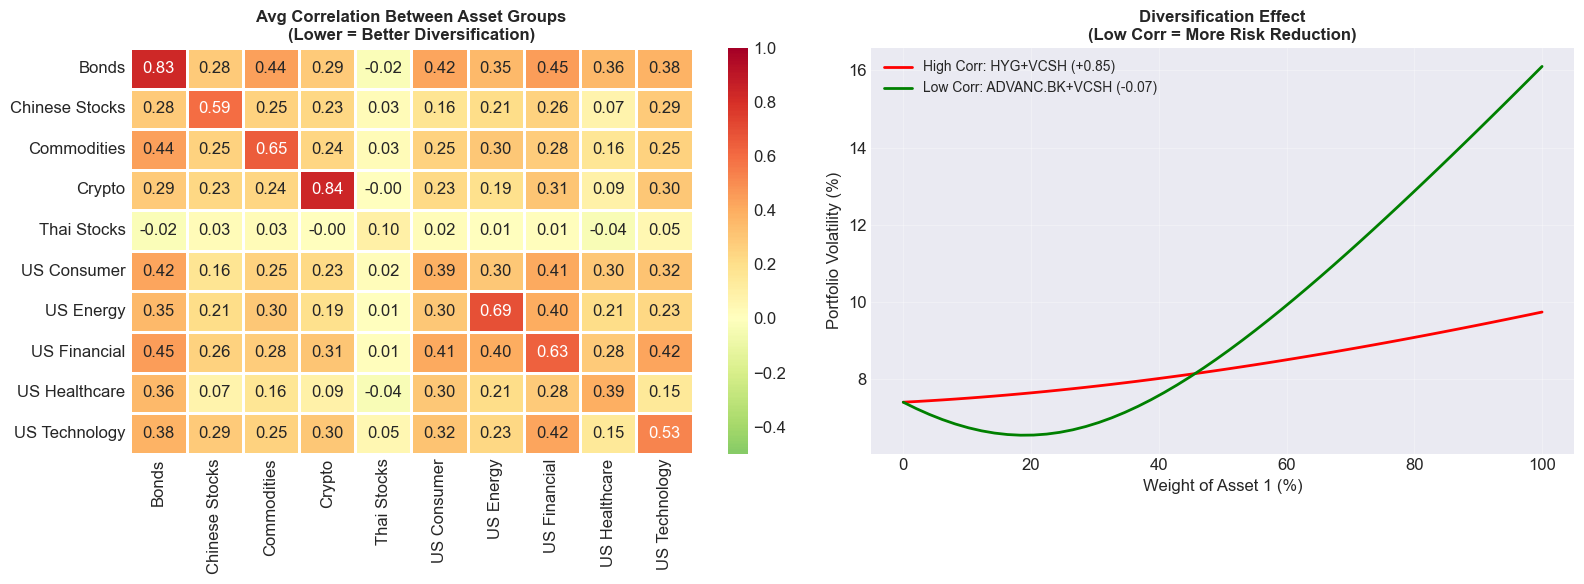

In [12]:
if len(portfolio_cols) > 1:
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    
    # Sector Correlation Heatmap
    sector_list = sorted(set(stock_sector_map.values()))
    sector_corr = pd.DataFrame(index=sector_list, columns=sector_list, dtype=float)
    for s1 in sector_list:
        t1s = [t for t in corr.columns if stock_sector_map.get(t) == s1]
        for s2 in sector_list:
            t2s = [t for t in corr.columns if stock_sector_map.get(t) == s2]
            vals = [corr.loc[a,b] for a in t1s for b in t2s if a != b]
            sector_corr.loc[s1, s2] = np.mean(vals) if vals else (1.0 if s1==s2 else 0.0)
    
    sns.heatmap(sector_corr.astype(float), annot=True, fmt=".2f", cmap="RdYlGn_r",
                center=0, vmin=-0.5, vmax=1, ax=axes[0], linewidths=1)
    axes[0].set_title("Avg Correlation Between Asset Groups\n(Lower = Better Diversification)",
                      fontsize=12, fontweight="bold")
    
    # Diversification Effect
    weights_range = np.linspace(0, 1, 50)
    vols_high = [two_asset_portfolio(high_a, high_b, w)[1]*100 for w in weights_range]
    vols_low = [two_asset_portfolio(low_a, low_b, w)[1]*100 for w in weights_range]
    
    axes[1].plot(weights_range*100, vols_high, "r-", linewidth=2,
                 label=f"High Corr: {high_a}+{high_b} ({high_c:+.2f})")
    axes[1].plot(weights_range*100, vols_low, "g-", linewidth=2,
                 label=f"Low Corr: {low_a}+{low_b} ({low_c:+.2f})")
    axes[1].set_xlabel("Weight of Asset 1 (%)")
    axes[1].set_ylabel("Portfolio Volatility (%)")
    axes[1].set_title("Diversification Effect\n(Low Corr = More Risk Reduction)",
                      fontsize=12, fontweight="bold")
    axes[1].legend(fontsize=10)
    axes[1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()